# Hey Pakize – Wake-Word Tespiti
MFCC özellikleri ve SVM ile Türkçe "Hey Pakize" ifadesini tanıyan ikili sınıflandırıcı.
- Veri: 378 kayıt (131 pozitif, 247 negatif)
- Yöntem: MFCC, augmentation, SVM (RBF), GridSearchCV, threshold analizi
- Sonuç: Test F1 ≈ 0.68

## 1. Kütüphaneler

In [ ]:
import os
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import librosa
import librosa.display
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

warnings.filterwarnings("ignore")
sns.set_context("notebook")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)

print("Hazır.")

Hazır.


## 2. Kurulum ve veri yolları

In [ ]:
# Colab için. Yerelde çalıştırıyorsan bu hücreyi atla.
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# Kendi veri yoluna göre değiştir
POZITIF_KLASOR = '/content/drive/MyDrive/hey_pakize_project/data_raw/Hey_Pakize_Positives'
NEGATIF_KLASOR = '/content/drive/MyDrive/hey_pakize_project/data_raw/Not_Hey_Pakize'

assert os.path.exists(POZITIF_KLASOR), f"Pozitif klasör bulunamadı: {POZITIF_KLASOR}"
assert os.path.exists(NEGATIF_KLASOR), f"Negatif klasör bulunamadı: {NEGATIF_KLASOR}"

BASE_OUT  = '/content/drive/MyDrive/hey_pakize_project/outputs_clean'
CSV_OUT   = os.path.join(BASE_OUT, 'csv')
MODEL_OUT = os.path.join(BASE_OUT, 'models')
FIG_OUT   = os.path.join(BASE_OUT, 'figures')

os.makedirs(CSV_OUT, exist_ok=True)
os.makedirs(MODEL_OUT, exist_ok=True)
os.makedirs(FIG_OUT, exist_ok=True)

print("Pozitif klasör:", POZITIF_KLASOR)
print("Negatif klasör:", NEGATIF_KLASOR)
print("Çıktı klasörleri hazır.")

## 3. Parametreler

In [ ]:
SAMPLE_RATE = 16000

N_MFCC = 13
N_FFT = 512
HOP_LENGTH = 160
WIN_LENGTH = 400
TOP_DB = 25

AUG_PER_FILE_POS = 3
AUG_PER_FILE_NEG = 1
NOISE_MIN, NOISE_MAX = 0.003, 0.015
SPEED_MIN, SPEED_MAX = 0.95, 1.05
PITCH_MIN, PITCH_MAX = -1.0, 1.0

TEST_SIZE = 0.20

FEATURE_DIM = N_MFCC * 6 + 8

print(f"N_MFCC = {N_MFCC}")
print(f"Feature boyutu = {FEATURE_DIM}")

N_MFCC = 13
Feature boyutu = 86


## 4. Veri yükleme

In [ ]:
def list_wav_files(folder, label):
    paths = sorted(Path(folder).glob("*.wav"))
    return pd.DataFrame({
        "filepath": [str(p) for p in paths],
        "filename": [p.name for p in paths],
        "label": [label] * len(paths)
    })

df_pos = list_wav_files(POZITIF_KLASOR, 1)
df_neg = list_wav_files(NEGATIF_KLASOR, 0)
df_files = pd.concat([df_pos, df_neg], ignore_index=True)

print(f"Pozitif: {len(df_pos)}")
print(f"Negatif: {len(df_neg)}")
print(f"Toplam : {len(df_files)}")

display(df_files.head())

## 5. Veri analizi (süre, peak)

In [ ]:
def inspect_audio_file(path, target_sr=SAMPLE_RATE, top_db=TOP_DB):
    y, sr = librosa.load(path, sr=None, mono=False)

    if y.ndim == 1:
        channels = 1
        y_mono = y
    else:
        channels = y.shape[0]
        y_mono = librosa.to_mono(y)

    duration_raw = len(y_mono) / sr

    if sr != target_sr:
        y_res = librosa.resample(y_mono, orig_sr=sr, target_sr=target_sr)
    else:
        y_res = y_mono

    y_trim, _ = librosa.effects.trim(y_res, top_db=top_db)
    duration_trim = len(y_trim) / target_sr
    peak = float(np.max(np.abs(y_res))) if len(y_res) > 0 else 0.0

    return {
        "orig_sr": sr,
        "channels": channels,
        "duration_raw_sec": duration_raw,
        "duration_trim_sec": duration_trim,
        "peak_abs": peak
    }

records = []
for _, row in df_files.iterrows():
    info = inspect_audio_file(row["filepath"])
    info["filepath"] = row["filepath"]
    info["filename"] = row["filename"]
    info["label"] = row["label"]
    records.append(info)

df_meta = pd.DataFrame(records)

print("Format özeti:")
print(f"16 kHz   : {(df_meta['orig_sr'] == 16000).sum()} / {len(df_meta)}")
print(f"Mono     : {(df_meta['channels'] == 1).sum()} / {len(df_meta)}")
print(f"Peak>0.99: {(df_meta['peak_abs'] > 0.99).sum()} dosya")

display(df_meta.head())

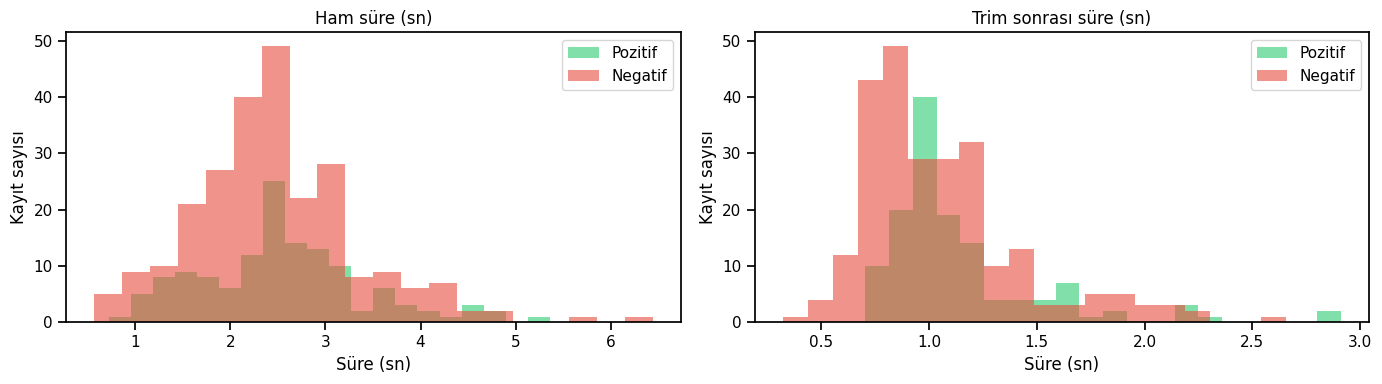

duration_raw_sec                                   duration_trim_sec  \
                 count   mean median    std    min   max             count   
label                                                                        
0                  247  2.463  2.390  0.870  0.567  6.44               247   
1                  131  2.526  2.465  0.878  0.719  5.36               131   

                                          
        mean median    std    min    max  
label                                     
0      1.048  0.960  0.369  0.320  2.656  
1      1.143  1.024  0.388  0.704  2.912

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, title in zip(
    axes,
    ["duration_raw_sec", "duration_trim_sec"],
    ["Ham süre (sn)", "Trim sonrası süre (sn)"]
):
    for lbl, color in [(1, "#2ecc71"), (0, "#e74c3c")]:
        data = df_meta.loc[df_meta["label"] == lbl, col]
        ax.hist(data, bins=20, alpha=0.6, color=color,
                label="Pozitif" if lbl == 1 else "Negatif")
    ax.set_title(title)
    ax.set_xlabel("Süre (sn)")
    ax.set_ylabel("Kayıt sayısı")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, "sure_dagilimi.png"), dpi=150, bbox_inches="tight")
plt.show()

display(
    df_meta.groupby("label")[["duration_raw_sec", "duration_trim_sec"]]
    .agg(["count", "mean", "median", "std", "min", "max"])
    .round(3)
)

## 6. Train/Test bölme

In [ ]:
df_train, df_test = train_test_split(
    df_files,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=df_files["label"]
)

df_train = df_train.reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

print("Train boyutu:", df_train.shape)
print("Test boyutu :", df_test.shape)

print("\nTrain sınıf dağılımı:")
print(df_train["label"].value_counts())

print("\nTest sınıf dağılımı:")
print(df_test["label"].value_counts())

Train boyutu: (302, 3)
Test boyutu : (76, 3)

Train sınıf dağılımı:
label
0    197
1    105
Name: count, dtype: int64

Test sınıf dağılımı:
label
0    50
1    26
Name: count, dtype: int64


In [ ]:
train_pos = df_train[df_train["label"] == 1].copy()

train_pos_trim_durations = []
for _, row in train_pos.iterrows():
    info = inspect_audio_file(row["filepath"])
    train_pos_trim_durations.append(info["duration_trim_sec"])

pos_p95 = float(np.quantile(train_pos_trim_durations, 0.95))
TARGET_DURATION_SEC = max(1.0, round(pos_p95, 2))
TARGET_SAMPLES = int(TARGET_DURATION_SEC * SAMPLE_RATE)

print(f"Train pozitif %95 süre  : {pos_p95:.3f} sn")
print(f"Hedef süre              : {TARGET_DURATION_SEC:.2f} sn")
print(f"Hedef örnek sayısı      : {TARGET_SAMPLES}")

Train pozitif %95 süre  : 2.097 sn
Hedef süre              : 2.10 sn
Hedef örnek sayısı      : 33600


## 7. Ön işleme ve özellik çıkarma (MFCC)

In [ ]:
def load_and_preprocess_audio(path, target_sr=SAMPLE_RATE, target_samples=TARGET_SAMPLES, top_db=TOP_DB):
    y, sr = librosa.load(path, sr=None, mono=True)

    if sr != target_sr:
        y = librosa.resample(y, orig_sr=sr, target_sr=target_sr)

    y_trim, _ = librosa.effects.trim(y, top_db=top_db)

    if len(y_trim) == 0:
        y_trim = np.zeros(1, dtype=np.float32)

    if len(y_trim) < target_samples:
        y_fixed = np.pad(y_trim, (0, target_samples - len(y_trim)), mode='constant')
    else:
        y_fixed = y_trim[:target_samples]

    return y_fixed.astype(np.float32)

def fix_length(y, target_samples=TARGET_SAMPLES):
    if len(y) < target_samples:
        return np.pad(y, (0, target_samples - len(y)), mode='constant')
    return y[:target_samples]

In [ ]:
def add_white_noise(y, noise_factor):
    noise = np.random.randn(len(y)).astype(np.float32)
    return np.clip(y + noise_factor * noise, -1.0, 1.0)

def change_speed(y, speed_rate):
    y2 = librosa.effects.time_stretch(y, rate=speed_rate)
    return fix_length(y2).astype(np.float32)

def change_pitch(y, sr, n_steps):
    y2 = librosa.effects.pitch_shift(y, sr=sr, n_steps=n_steps)
    return fix_length(y2).astype(np.float32)

def random_volume(y):
    factor = np.random.uniform(0.8, 1.2)
    return np.clip(y * factor, -1.0, 1.0).astype(np.float32)

def random_augment(y, sr=SAMPLE_RATE):
    y_aug = y.copy()

    operations = []

    if np.random.rand() < 0.6:
        operations.append("noise")
    if np.random.rand() < 0.4:
        operations.append("speed")
    if np.random.rand() < 0.4:
        operations.append("pitch")
    if np.random.rand() < 0.3:
        operations.append("volume")

    if len(operations) > 2:
        operations = random.sample(operations, 2)

    for op in operations:
        if op == "noise":
            y_aug = add_white_noise(y_aug, np.random.uniform(NOISE_MIN, NOISE_MAX))
        elif op == "speed":
            y_aug = change_speed(y_aug, np.random.uniform(SPEED_MIN, SPEED_MAX))
        elif op == "pitch":
            y_aug = change_pitch(y_aug, sr, np.random.uniform(PITCH_MIN, PITCH_MAX))
        elif op == "volume":
            y_aug = random_volume(y_aug)

    return fix_length(y_aug)

print("Hafif augmentation hazır.")

Hafif augmentation hazır.


In [ ]:
def extract_mfcc_features(y, sr=SAMPLE_RATE, n_mfcc=N_MFCC,
                          n_fft=N_FFT, hop_length=HOP_LENGTH, win_length=WIN_LENGTH):
    mfcc = librosa.feature.mfcc(
        y=y, sr=sr, n_mfcc=n_mfcc,
        n_fft=n_fft, hop_length=hop_length, win_length=win_length
    )

    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    zcr = librosa.feature.zero_crossing_rate(y)
    cent = librosa.feature.spectral_centroid(y=y, sr=sr)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr)
    rms = librosa.feature.rms(y=y)

    feats = np.concatenate([
        np.mean(mfcc, axis=1),   np.std(mfcc, axis=1),
        np.mean(delta, axis=1),  np.std(delta, axis=1),
        np.mean(delta2, axis=1), np.std(delta2, axis=1),
        [
            np.mean(zcr), np.std(zcr),
            np.mean(cent), np.std(cent),
            np.mean(rolloff), np.std(rolloff),
            np.mean(rms), np.std(rms)
        ]
    ]).astype(np.float32)

    return feats, mfcc

test_signal = np.zeros(TARGET_SAMPLES, dtype=np.float32)
test_feat, test_mfcc = extract_mfcc_features(test_signal)

print("Feature boyutu:", len(test_feat))
assert len(test_feat) == FEATURE_DIM, "Feature boyutu beklenenden farklı!"

Feature boyutu: 86


Örnek feature boyutu: 86


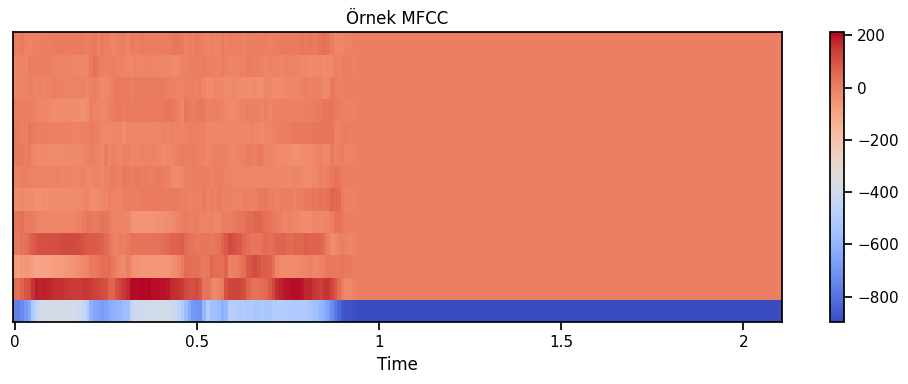

In [ ]:
sample_path = df_train.iloc[0]["filepath"]
y_example = load_and_preprocess_audio(sample_path)
feat_vec, mfcc_mat = extract_mfcc_features(y_example)

print("Örnek feature boyutu:", len(feat_vec))

plt.figure(figsize=(10, 4))
librosa.display.specshow(
    mfcc_mat, x_axis='time', sr=SAMPLE_RATE, hop_length=HOP_LENGTH
)
plt.colorbar()
plt.title("Örnek MFCC")
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, "ornek_mfcc.png"), dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
def build_col_names(n=N_MFCC):
    return (
        [f"mfcc_mean_{i+1}" for i in range(n)] +
        [f"mfcc_std_{i+1}" for i in range(n)] +
        [f"delta_mean_{i+1}" for i in range(n)] +
        [f"delta_std_{i+1}" for i in range(n)] +
        [f"delta2_mean_{i+1}" for i in range(n)] +
        [f"delta2_std_{i+1}" for i in range(n)] +
        [
            "zcr_mean", "zcr_std",
            "cent_mean", "cent_std",
            "rolloff_mean", "rolloff_std",
            "rms_mean", "rms_std"
        ]
    )

COL_NAMES = build_col_names()
print("Sütun sayısı:", len(COL_NAMES))
print("Feature boyutu:", FEATURE_DIM)
assert len(COL_NAMES) == FEATURE_DIM

Sütun sayısı: 86
Feature boyutu: 86


In [ ]:
def build_feature_dataframe(df_input):
    rows = []

    for _, row in df_input.iterrows():
        y = load_and_preprocess_audio(row["filepath"])
        feat, _ = extract_mfcc_features(y)

        item = {
            "dosya_adi": row["filename"],
            "filepath": row["filepath"],
            "etiket": int(row["label"])
        }

        for col, val in zip(COL_NAMES, feat):
            item[col] = float(val)

        rows.append(item)

    return pd.DataFrame(rows)

## 8. Özellik tablolarını oluşturma

In [ ]:
df_train_orig = build_feature_dataframe(df_train)
df_test_orig  = build_feature_dataframe(df_test)

print("Train orijinal shape:", df_train_orig.shape)
print("Test orijinal shape :", df_test_orig.shape)

display(df_train_orig.head(3))

In [ ]:
train_csv_path = os.path.join(CSV_OUT, "train_original_features.csv")
test_csv_path  = os.path.join(CSV_OUT, "test_original_features.csv")

df_train_orig.to_csv(train_csv_path, index=False, encoding="utf-8")
df_test_orig.to_csv(test_csv_path, index=False, encoding="utf-8")

print("Kaydedildi:")
print(train_csv_path)
print(test_csv_path)

Kaydedildi:
/content/drive/MyDrive/hey_pakize_project/outputs_clean/csv/train_original_features.csv
/content/drive/MyDrive/hey_pakize_project/outputs_clean/csv/test_original_features.csv


## 9. Augmentation (sadece train)

In [ ]:
def build_augmented_feature_dataframe(df_input):
    aug_rows = []

    for _, row in df_input.iterrows():
        y = load_and_preprocess_audio(row["filepath"])
        label = int(row["label"])
        n_aug = AUG_PER_FILE_POS if label == 1 else AUG_PER_FILE_NEG

        for i in range(n_aug):
            y_aug = random_augment(y)
            feat_aug, _ = extract_mfcc_features(y_aug)

            item = {
                "dosya_adi": f"aug_{i+1}_{row['filename']}",
                "filepath": row["filepath"],
                "etiket": label
            }

            for col, val in zip(COL_NAMES, feat_aug):
                item[col] = float(val)

            aug_rows.append(item)

    return pd.DataFrame(aug_rows)

df_train_aug = build_augmented_feature_dataframe(df_train)

print("Augmented train shape:", df_train_aug.shape)
display(df_train_aug.head(3))

In [ ]:
df_train_full = pd.concat([df_train_orig, df_train_aug], ignore_index=True)

print("Train original :", df_train_orig.shape)
print("Train augmented:", df_train_aug.shape)
print("Train final    :", df_train_full.shape)
print("Test final     :", df_test_orig.shape)

print("\nTrain final sınıf dağılımı:")
print(df_train_full["etiket"].value_counts())

print("\nTest sınıf dağılımı:")
print(df_test_orig["etiket"].value_counts())

Train original : (302, 89)
Train augmented: (512, 89)
Train final    : (814, 89)
Test final     : (76, 89)

Train final sınıf dağılımı:
etiket
1    420
0    394
Name: count, dtype: int64

Test sınıf dağılımı:
etiket
0    50
1    26
Name: count, dtype: int64


In [ ]:
train_full_csv_path = os.path.join(CSV_OUT, "train_full_augmented_features.csv")

df_train_full.to_csv(train_full_csv_path, index=False, encoding="utf-8")

print("Kaydedildi:")
print(train_full_csv_path)

Kaydedildi:
/content/drive/MyDrive/hey_pakize_project/outputs_clean/csv/train_full_augmented_features.csv


In [ ]:
feature_cols = COL_NAMES

X_train = df_train_full[feature_cols].values.astype(np.float32)
y_train = df_train_full["etiket"].values.astype(int)

X_test = df_test_orig[feature_cols].values.astype(np.float32)
y_test = df_test_orig["etiket"].values.astype(int)

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)
print("X_test :", X_test.shape)
print("y_test :", y_test.shape)

X_train: (814, 86)
y_train: (814,)
X_test : (76, 86)
y_test : (76,)


## 10. Görselleştirme (t-SNE)

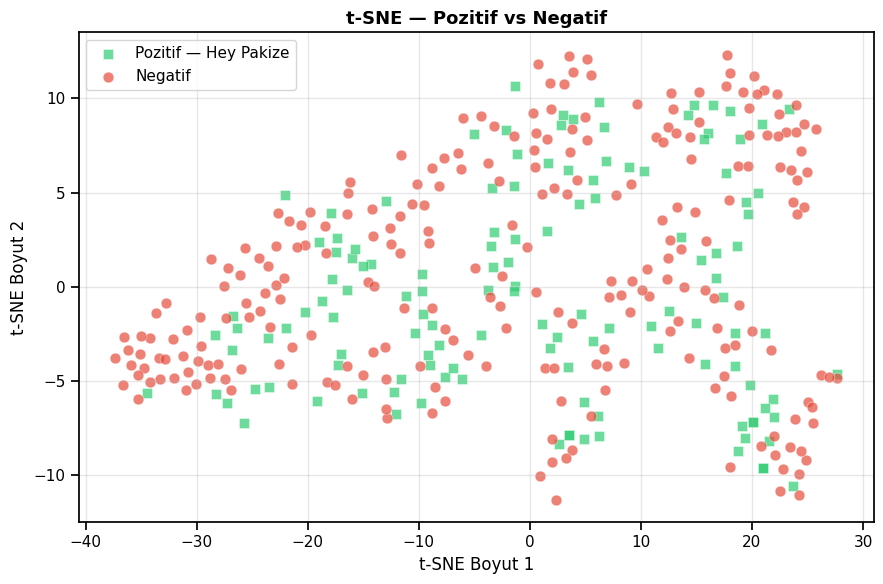

In [ ]:
from sklearn.manifold import TSNE

df_tsne = pd.concat([df_train_orig, df_test_orig], ignore_index=True)
X_tsne = df_tsne[feature_cols].values
y_tsne = df_tsne["etiket"].values

perplexity = min(30, max(5, len(X_tsne) // 4))

X_2d = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=RANDOM_STATE,
    init="pca"
).fit_transform(X_tsne)

plt.figure(figsize=(9, 6))

for cls, color, marker, lbl in [
    (1, "#2ecc71", "s", "Pozitif — Hey Pakize"),
    (0, "#e74c3c", "o", "Negatif")
]:
    idx = y_tsne == cls
    plt.scatter(
        X_2d[idx, 0],
        X_2d[idx, 1],
        c=color,
        marker=marker,
        label=lbl,
        alpha=0.7,
        edgecolors="white",
        linewidths=0.4,
        s=60
    )

plt.title("t-SNE — Pozitif vs Negatif", fontsize=13, fontweight="bold")
plt.xlabel("t-SNE Boyut 1")
plt.ylabel("t-SNE Boyut 2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, "tsne_clean.png"), dpi=150, bbox_inches="tight")
plt.show()

## 11. Model 1: SVM + GridSearch

In [ ]:
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, class_weight={0:1, 1:2}, random_state=RANDOM_STATE))
])

param_grid = {
    "svc__kernel": ["rbf"],
    "svc__C": [0.1, 1, 10, 20],
    "svc__gamma": ["scale", 0.01, 0.001]
}

grid = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("En iyi parametreler:", grid.best_params_)
print("En iyi CV skoru    :", round(grid.best_score_, 4))

best_model = grid.best_estimator_

Fitting 5 folds for each of 12 candidates, totalling 60 fits
En iyi parametreler: {'svc__C': 20, 'svc__gamma': 0.01, 'svc__kernel': 'rbf'}
En iyi CV skoru    : 0.8534


In [ ]:
probs = best_model.predict_proba(X_test)[:,1]
y_pred = (probs >= 0.35).astype(int)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, zero_division=0)
rec = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)

print("Test Sonuçları")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Negatif", "Pozitif"], zero_division=0))

Test Sonuçları
Accuracy : 0.7237
Precision: 0.5806
Recall   : 0.6923
F1-score : 0.6316

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.82      0.74      0.78        50
     Pozitif       0.58      0.69      0.63        26

    accuracy                           0.72        76
   macro avg       0.70      0.72      0.71        76
weighted avg       0.74      0.72      0.73        76



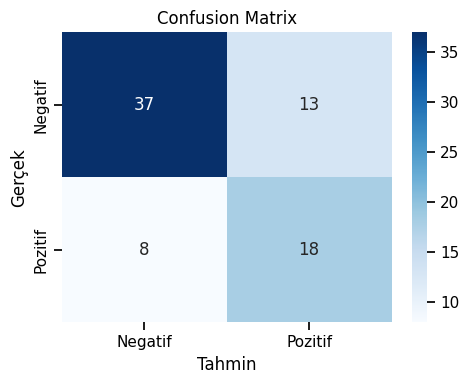

In [ ]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Negatif", "Pozitif"],
            yticklabels=["Negatif", "Pozitif"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig(os.path.join(FIG_OUT, "confusion_matrix.png"), dpi=150, bbox_inches="tight")
plt.show()

## 12. Model 1: Threshold analizi

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd

probs = best_model.predict_proba(X_test)[:, 1]

results = []

for th in [0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred = (probs >= th).astype(int)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)

    results.append({
        "threshold": th,
        "accuracy": round(acc, 4),
        "precision": round(prec, 4),
        "recall": round(rec, 4),
        "f1": round(f1, 4)
    })

results_df = pd.DataFrame(results)
display(results_df)

,threshold,accuracy,precision,recall,f1
0,0.30,0.7105,0.5625,0.6923,0.6207
1,0.35,0.7237,0.5806,0.6923,0.6316
2,0.40,0.7763,0.6667,0.6923,0.6792
3,0.45,0.7895,0.7083,0.6538,0.6800
4,0.50,0.7763,0.6957,0.6154,0.6531


In [ ]:
best_row = results_df.loc[results_df["f1"].idxmax()]
BEST_THRESHOLD = float(best_row["threshold"])

print("En iyi threshold:", BEST_THRESHOLD)
display(best_row)

En iyi threshold: 0.45


,3
threshold,0.4500
accuracy,0.7895
precision,0.7083
recall,0.6538
f1,0.6800


In [ ]:
y_pred_final = (probs >= BEST_THRESHOLD).astype(int)

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("=== FINAL SONUÇ ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final), 4))
print("Precision:", round(precision_score(y_test, y_pred_final, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, y_pred_final, zero_division=0), 4))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_final, target_names=["Negatif", "Pozitif"], zero_division=0))

=== FINAL SONUÇ ===
Accuracy : 0.7895
Precision: 0.7083
Recall   : 0.6538
F1-score : 0.68

Classification Report:
              precision    recall  f1-score   support

     Negatif       0.83      0.86      0.84        50
     Pozitif       0.71      0.65      0.68        26

    accuracy                           0.79        76
   macro avg       0.77      0.76      0.76        76
weighted avg       0.79      0.79      0.79        76



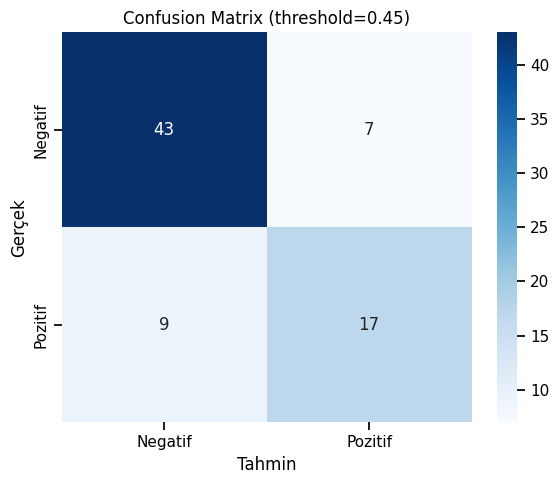

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred_final)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negatif", "Pozitif"],
    yticklabels=["Negatif", "Pozitif"]
)
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title(f"Confusion Matrix (threshold={BEST_THRESHOLD})")
plt.tight_layout()
plt.show()

## 13. Model 2: Daha geniş arama

In [ ]:
# ── Model 2: Geniş param_grid ile eğit ──
pipeline2 = Pipeline([
    ("scaler", StandardScaler()),
    ("svc", SVC(probability=True, class_weight={0:1, 1:2}, random_state=RANDOM_STATE))
])

param_grid2 = {
    "svc__kernel": ["rbf"],
    "svc__C":      [0.1, 0.5, 1, 5, 10, 20, 50],
    "svc__gamma":  ["scale", 0.1, 0.01, 0.001, 0.0001]
}

grid2 = GridSearchCV(
    pipeline2, param_grid=param_grid2,
    scoring="f1", cv=5, n_jobs=-1, verbose=1
)
grid2.fit(X_train, y_train)

best_model2 = grid2.best_estimator_
print("[Model 2] En iyi parametreler:", grid2.best_params_)
print("[Model 2] En iyi CV skoru    :", round(grid2.best_score_, 4))


Fitting 5 folds for each of 35 candidates, totalling 175 fits
[Model 2] En iyi parametreler: {'svc__C': 50, 'svc__gamma': 0.001, 'svc__kernel': 'rbf'}
[Model 2] En iyi CV skoru    : 0.8614


,threshold,accuracy,precision,recall,f1
0,0.25,0.6711,0.5143,0.6923,0.5902
1,0.30,0.6711,0.5152,0.6538,0.5763
2,0.35,0.6711,0.5161,0.6154,0.5614
3,0.40,0.6974,0.5517,0.6154,0.5818
4,0.45,0.7105,0.5769,0.5769,0.5769
5,0.50,0.7237,0.6087,0.5385,0.5714


[Model 2] En iyi threshold: 0.25

=== Model 2 FINAL SONUÇ (threshold=0.25) ===
Accuracy : 0.6711
Precision: 0.5143
Recall   : 0.6923
F1-score : 0.5902
              precision    recall  f1-score   support

     Negatif       0.80      0.66      0.73        50
     Pozitif       0.51      0.69      0.59        26

    accuracy                           0.67        76
   macro avg       0.66      0.68      0.66        76
weighted avg       0.71      0.67      0.68        76



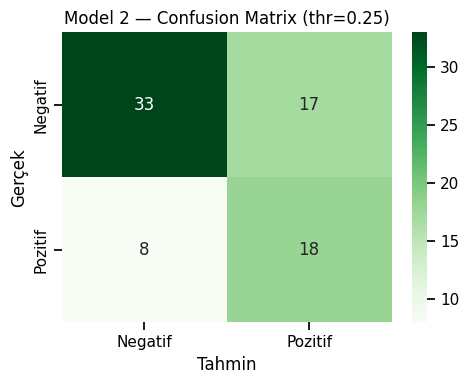

In [ ]:
# ── Model 2: Threshold araması ──
probs2 = best_model2.predict_proba(X_test)[:, 1]

results2 = []
for th in [0.25, 0.30, 0.35, 0.40, 0.45, 0.50]:
    y_pred2 = (probs2 >= th).astype(int)
    results2.append({
        "threshold": th,
        "accuracy":  round(accuracy_score(y_test, y_pred2), 4),
        "precision": round(precision_score(y_test, y_pred2, zero_division=0), 4),
        "recall":    round(recall_score(y_test, y_pred2, zero_division=0), 4),
        "f1":        round(f1_score(y_test, y_pred2, zero_division=0), 4)
    })

results_df2 = pd.DataFrame(results2)
display(results_df2)

BEST_TH_M2 = float(results_df2.loc[results_df2["f1"].idxmax(), "threshold"])
print("[Model 2] En iyi threshold:", BEST_TH_M2)

# Final sonuç
y_pred_final2 = (probs2 >= BEST_TH_M2).astype(int)
print(f"\n=== Model 2 FINAL SONUÇ (threshold={BEST_TH_M2}) ===")
print("Accuracy :", round(accuracy_score(y_test, y_pred_final2), 4))
print("Precision:", round(precision_score(y_test, y_pred_final2, zero_division=0), 4))
print("Recall   :", round(recall_score(y_test, y_pred_final2, zero_division=0), 4))
print("F1-score :", round(f1_score(y_test, y_pred_final2, zero_division=0), 4))
print(classification_report(y_test, y_pred_final2,
      target_names=["Negatif", "Pozitif"], zero_division=0))

# Confusion matrix
cm2 = confusion_matrix(y_test, y_pred_final2)
plt.figure(figsize=(5, 4))
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens",
            xticklabels=["Negatif", "Pozitif"],
            yticklabels=["Negatif", "Pozitif"])
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.title(f"Model 2 — Confusion Matrix (thr={BEST_TH_M2})")
plt.tight_layout()
plt.show()

## 14. Modelleri kaydetme

In [ ]:
# ── Model 1 ve Model 2: En iyi threshold ile kaydet ──
from datetime import datetime
from google.colab import files

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

for model_tag, model_obj, best_th in [
    ("model1", best_model,  BEST_THRESHOLD),
    ("model2", best_model2, BEST_TH_M2),
]:
    probs_save  = model_obj.predict_proba(X_test)[:, 1]
    y_pred_save = (probs_save >= best_th).astype(int)

    acc_s  = round(accuracy_score(y_test, y_pred_save), 4)
    prec_s = round(precision_score(y_test, y_pred_save, zero_division=0), 4)
    rec_s  = round(recall_score(y_test, y_pred_save, zero_division=0), 4)
    f1_s   = round(f1_score(y_test, y_pred_save, zero_division=0), 4)

    fname = f"svm_{model_tag}_thr{best_th}_{timestamp}.joblib"
    fpath = os.path.join(MODEL_OUT, fname)
    joblib.dump(model_obj, fpath)

    print(f"[{model_tag}]  threshold={best_th}")
    print(f"  Acc={acc_s}  Prec={prec_s}  Rec={rec_s}  F1={f1_s}")
    print(f"  → {fpath}")
    files.download(fpath)
    print()


[model1]  threshold=0.45
  Acc=0.7895  Prec=0.7083  Rec=0.6538  F1=0.68
  → /content/drive/MyDrive/hey_pakize_project/outputs_clean/models/svm_model1_thr0.45_20260319_113138.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[model2]  threshold=0.25
  Acc=0.6711  Prec=0.5143  Rec=0.6923  F1=0.5902
  → /content/drive/MyDrive/hey_pakize_project/outputs_clean/models/svm_model2_thr0.25_20260319_113138.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>